In [1]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "CMU Serif",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)


## Vaccine demand

In [6]:
import pandas as pd

# Load the Excel file
# file_path = '../production_capacity_updated.xlsx'
file_path = 'demand_10_yr.xlsx'

# Read the 'Medium_Capacity' sheet
df = pd.read_excel(file_path, header=1)
df


,Segment,Vaccine,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
0,LIC,Measles,6.356171e+07,6.586305e+07,6.623499e+07,7.054581e+07,7.456946e+07,7.221816e+07,7.575254e+07,7.557326e+07,9.914052e+07,5.838534e+07,4.690584e+07
1,LMIC,Measles,1.501855e+07,1.581827e+07,1.303176e+07,1.607806e+07,1.158262e+07,1.793076e+07,1.566441e+07,1.985228e+07,2.125444e+07,5.179449e+07,7.787345e+07
2,LIC,MMR,4.944286e+05,1.252693e+06,1.431844e+06,1.643921e+06,7.352009e+05,4.736403e+05,1.876589e+06,1.433166e+06,1.334603e+06,1.208205e+06,1.747397e+06
3,LMIC,MMR,1.440112e+07,1.466424e+07,1.500846e+07,1.540787e+07,2.501792e+07,2.604284e+07,2.617725e+07,2.653070e+07,3.811979e+07,4.000490e+07,4.117935e+07
4,LIC,MR,1.486574e+07,1.903827e+05,1.861428e+05,1.766434e+05,1.700953e+05,1.667486e+05,1.824802e+05,1.780173e+05,4.227330e+05,1.017322e+06,1.071928e+06
5,LMIC,MR,1.842812e+06,1.651850e+07,1.643510e+07,1.673566e+07,1.782070e+07,3.205785e+07,3.582782e+07,3.546046e+07,2.067053e+07,2.133580e+07,2.131276e+07


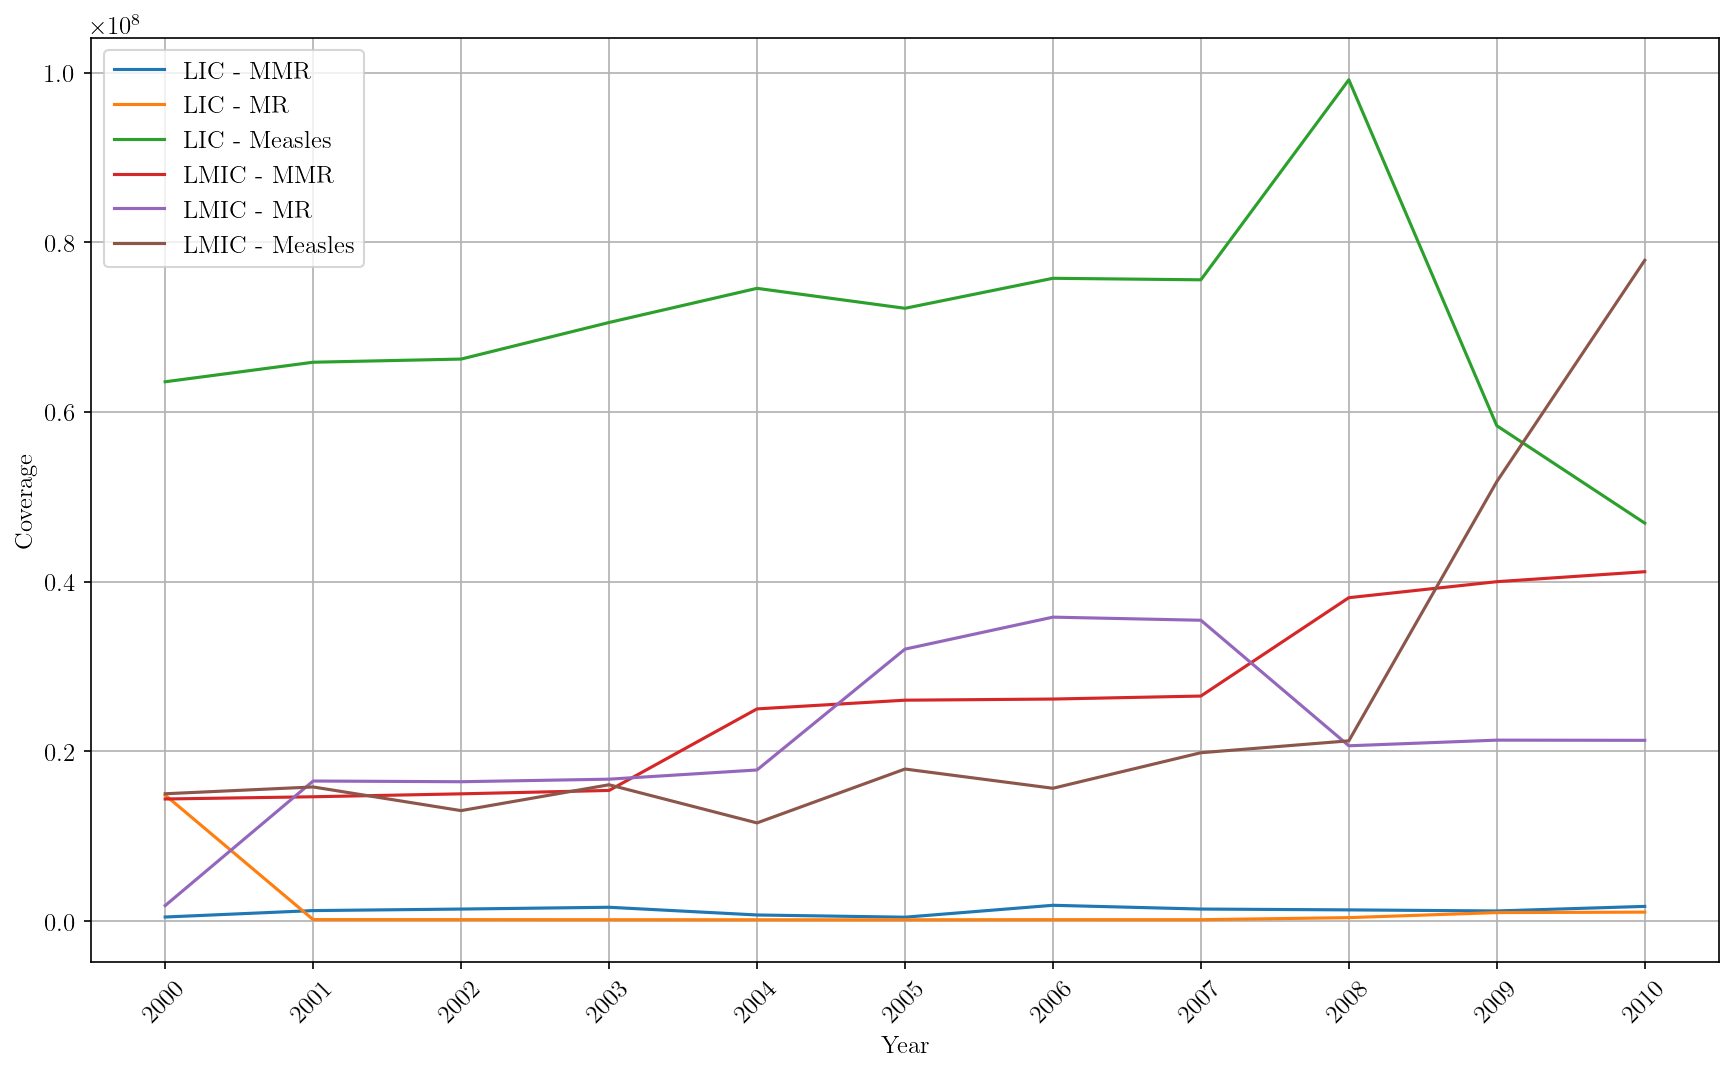

In [10]:
df = data_medium_capacity
# Plotting
fig, ax = plt.subplots(figsize=(14, 8))

for key, grp in df.groupby(['Segment', 'Vaccine']):
    ax.plot(grp.columns[2:], grp.iloc[0, 2:], label=f'{key[0]} - {key[1]}')

ax.legend()
# ax.set_title('Measles Containing Vaccine Coverage Over Time by Country Segment and Vaccine')
ax.set_xlabel('Year')
ax.set_ylabel('Coverage')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('MMR_10_YR.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()


## Antigen Demand

In [14]:
# Load the Excel file
file_path = 'MVP10_random_normal_forecast_data.xlsx'

# Read the 'Medium_Capacity' sheet
df_vaccine = pd.read_excel(file_path, header=0)
df_vaccine

,Vaccine,1,2,3,4,5,6,7,8,9,10
0,Measles,4.414068e+08,4.591713e+08,5.003304e+08,5.144921e+08,6.792166e+08,7.845714e+08,8.706271e+08,8.151641e+08,8.978366e+08,8.117790e+08
1,Mumps,2.989608e+07,3.444858e+07,2.928330e+07,3.688535e+07,4.370853e+07,5.433872e+07,5.478849e+07,5.593094e+07,5.561017e+07,7.080045e+07
2,Rubella,4.004703e+08,3.912455e+08,4.101467e+08,4.716257e+08,4.608276e+08,5.616485e+08,6.036525e+08,5.766439e+08,8.688170e+08,7.410375e+08
3,Diphtheria,6.640577e+08,6.757999e+08,7.322240e+08,8.787500e+08,7.643547e+08,1.235732e+09,1.399794e+09,1.469949e+09,1.732645e+09,1.669050e+09
4,Tetanus,6.099161e+08,6.415636e+08,6.744107e+08,7.251900e+08,7.326312e+08,6.941943e+08,6.623624e+08,7.159264e+08,7.174528e+08,7.547585e+08
5,Pertussis,3.514345e+08,3.462316e+08,3.443164e+08,3.510433e+08,3.892433e+08,3.719274e+08,4.141839e+08,3.684699e+08,3.743146e+08,3.820773e+08
6,Hepatitis_B,3.861397e+08,3.499688e+08,4.079808e+08,4.419819e+08,4.041173e+08,4.804640e+08,4.755972e+08,3.874333e+08,4.453655e+08,4.880969e+08
7,Hib,3.025612e+08,3.215282e+08,3.107278e+08,3.219790e+08,3.296795e+08,3.854332e+08,3.639696e+08,3.751639e+08,3.865013e+08,4.140040e+08
8,Polio,5.976856e+08,6.554911e+08,7.204843e+08,7.173324e+08,7.746624e+08,8.174290e+08,9.102866e+08,8.825939e+08,9.031089e+08,1.004736e+09
9,HPV,2.871809e+07,3.618551e+07,4.089370e+07,4.580123e+07,5.375822e+07,5.921739e+07,6.987050e+07,7.187569e+07,8.127103e+07,8.653830e+07


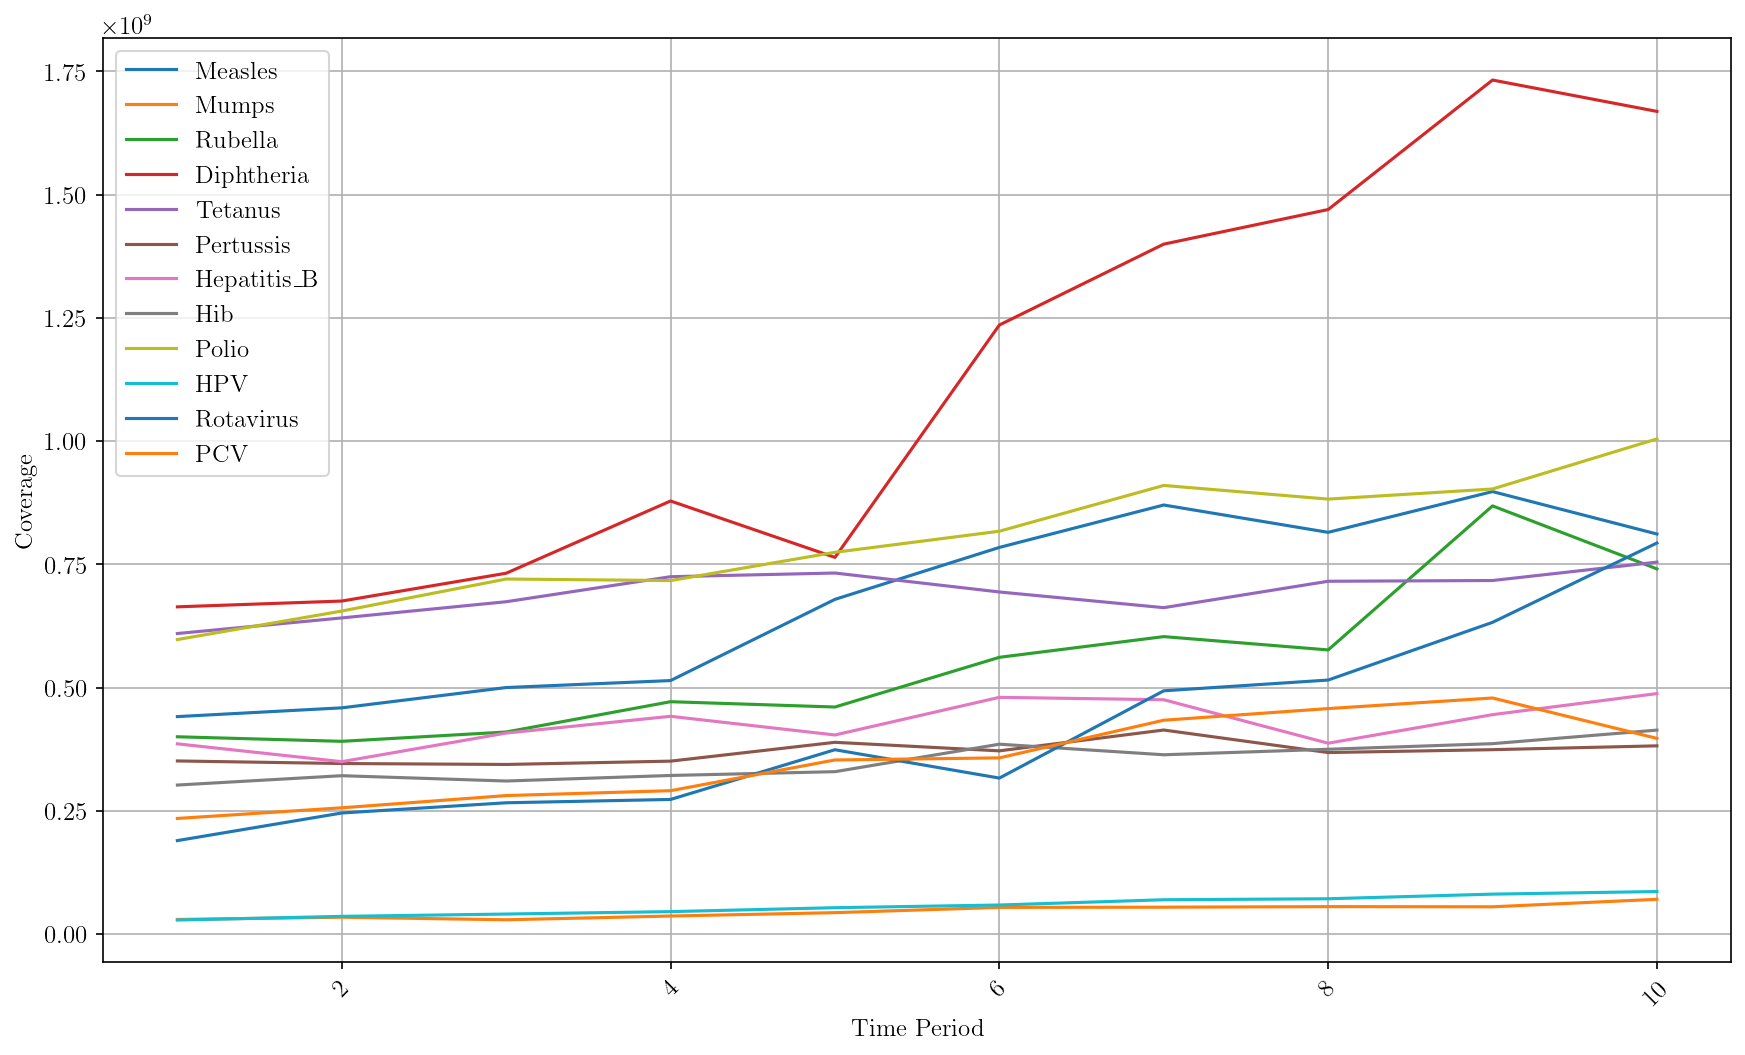

In [16]:
# Plotting without grouping by anything
fig, ax = plt.subplots(figsize=(14, 8))

for i, row in df_vaccine.iterrows():
    ax.plot(df_vaccine.columns[1:], row[1:], label=row['Vaccine'])

ax.legend()
# ax.set_title('Vaccine Coverage Over Time')
ax.set_xlabel('Time Period')
ax.set_ylabel('Coverage')
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('demand.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()
